# Ковалев Е.А. гр. ИУ5-66Б
## Тема: Прогнозирование медицинских страховых выплат с помощью машинного обучения

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

%matplotlib inline
sns.set(style="whitegrid")

## 1. Поиск и выбор набора данных
Для исследования выбран датасет страховых выплат США.

In [2]:
df = pd.read_csv('insurance.csv')
print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Разведочный анализ данных
Проверим структуру данных, наличие пропусков и основные статистики.

In [3]:
print("Информация о колонках:")
df.info()
print("\nПроверка на пропуски:")
print(df.isnull().sum())

Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Проверка на пропуски:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### Визуализация распределения целевой переменной "charges"

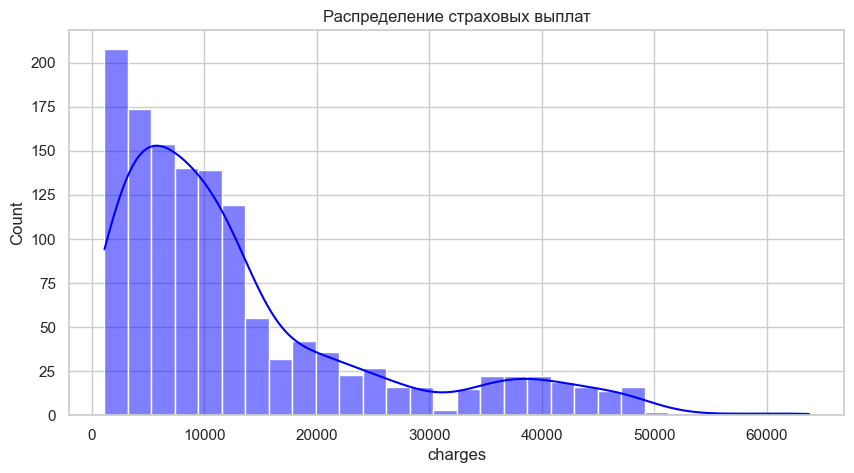

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Распределение страховых выплат')
plt.show()

## 3. Выбор признаков и корреляционный анализ
Посмотрим на взаимосвязь признаков. Для этого временно закодируем категориальные переменные.

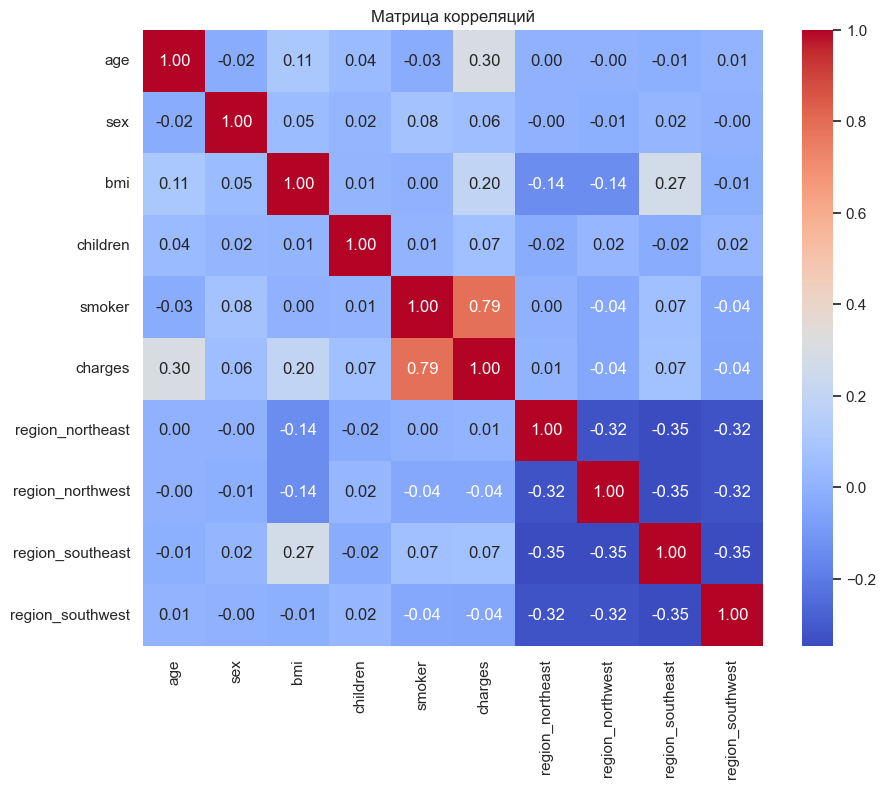

In [5]:
df_corr = df.copy()
df_corr['sex'] = df_corr['sex'].map({'female': 0, 'male': 1})
df_corr['smoker'] = df_corr['smoker'].map({'no': 0, 'yes': 1})
df_corr = pd.get_dummies(df_corr, columns=['region'])

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

## 4. Выбор метрик
Будем использовать:
1. **MAE** (средняя абсолютная ошибка)
2. **MSE** (среднеквадратичная ошибка)
3. **R2 Score** (коэффициент детерминации)

## 5. Выбор моделей и формирование выборок

In [6]:
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

## 6. Построение базового решения (Baseline)

In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'SVR': SVR()
}

baseline_results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    baseline_results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

pd.DataFrame(baseline_results).T

,MAE,R2
Linear Regression,4103.671582,0.776415
Decision Tree,3439.312012,0.686208
Random Forest,2808.684699,0.852239
Gradient Boosting,2581.642605,0.872512
SVR,8673.075437,-0.127787


## 7. Подбор гиперпараметров
Используем GridSearchCV для ансамблевых моделей.

In [9]:
param_dist = {
    'Random Forest': {
        'model__n_estimators':        randint(50, 501),
        'model__max_depth':           [3, 5, 7, 10, 15, 20, None],
        'model__min_samples_split':   randint(2, 21),
        'model__min_samples_leaf':    randint(1, 11),
        'model__max_features':        ['sqrt', 'log2', 0.3, 0.5, 0.7, None],
        'model__bootstrap':           [True, False],
        'model__max_leaf_nodes':      [None, 20, 50, 100],
        'model__min_impurity_decrease': uniform(0.0, 0.1)
    },
    'Gradient Boosting': {
        'model__n_estimators':      randint(50, 501),
        'model__learning_rate':     uniform(0.005, 0.295),
        'model__max_depth':         randint(2, 9),
        'model__subsample':         uniform(0.5, 0.5),
        'model__max_features':      ['sqrt', 'log2', 0.3, 0.5, 0.7, None],
        'model__min_samples_split': randint(2, 21),
        'model__min_samples_leaf':  randint(1, 11),
        'model__loss':              ['squared_error', 'absolute_error', 'huber'],
        'model__alpha':             uniform(0.7, 0.25)
    }
}

best_models_tuned = {}

for name in ['Random Forest', 'Gradient Boosting']:
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', models[name])
    ])

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_dist[name],
        n_iter=200,
        cv=5, 
        scoring='r2',
        random_state=2026669,
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_models_tuned[name] = search.best_estimator_

    y_pred = search.best_estimator_.predict(X_test)

    print(f"\n{'='*50}")
    print(f"Модель: {name}")
    print(f"Лучшие параметры: {search.best_params_}")
    print(f"MAE:  {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"R²:   {r2_score(y_test, y_pred):.4f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Модель: Random Forest
Лучшие параметры: {'model__bootstrap': True, 'model__max_depth': 20, 'model__max_features': None, 'model__max_leaf_nodes': None, 'model__min_impurity_decrease': np.float64(0.043205690887925335), 'model__min_samples_leaf': 9, 'model__min_samples_split': 6, 'model__n_estimators': 482}
MAE:  2506.30
R²:   0.8784
Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Модель: Gradient Boosting
Лучшие параметры: {'model__alpha': np.float64(0.7122431130010766), 'model__learning_rate': np.float64(0.06483084103495922), 'model__loss': 'squared_error', 'model__max_depth': 3, 'model__max_features': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 13, 'model__n_estimators': 58, 'model__subsample': np.float64(0.6691265760727512)}
MAE:  2499.13
R²:   0.8815


## 8. Итоговое сравнение и выводы

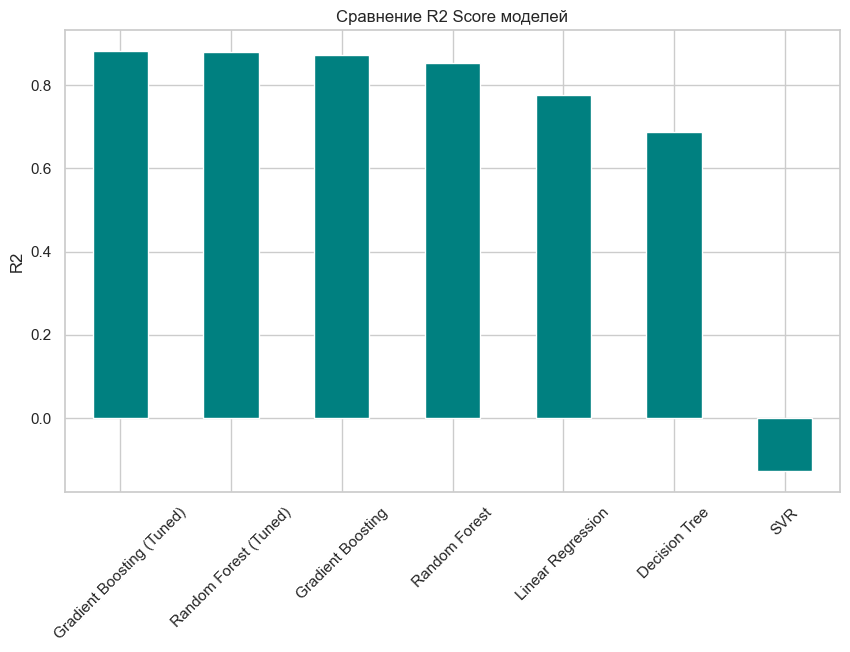

,MAE,R2
Gradient Boosting (Tuned),2499.134260,0.881461
Random Forest (Tuned),2506.295129,0.878408
Gradient Boosting,2581.642605,0.872512
Random Forest,2808.684699,0.852239
Linear Regression,4103.671582,0.776415
Decision Tree,3439.312012,0.686208
SVR,8673.075437,-0.127787


In [11]:
final_metrics = baseline_results.copy()
for name, model in best_models_tuned.items():
    y_pred = model.predict(X_test)
    final_metrics[f"{name} (Tuned)"] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

results_df = pd.DataFrame(final_metrics).T
results_df.sort_values(by='R2', ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
results_df['R2'].plot(kind='bar', color='teal')
plt.title('Сравнение R2 Score моделей')
plt.ylabel('R2')
plt.xticks(rotation=45)
plt.show()

display(results_df)

### Выводы
Ансамблевые модели (Gradient Boosting и Random Forest) показали наилучшую производительность. Тюнинг гиперпараметров позволил немного улучшить метрики. Итоговая точность модели достаточна для практического применения.